<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Curso: Visualización para la Analítica de Datos</p>

<p style="text-align: center;"> Grupo: 01 </p>

<p style="text-align: center;"> Tarea 02 - Componente práctico del Curso</p>

<p style="text-align: center;">  Estudiante: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellín, Septiembre 2026</p>

In [1]:
import importlib
import subprocess
import sys

librerias_proyecto = {"numpy": "numpy",
             "pandas": "pandas",
             "matplotlib":"matplotlib",
             "seaborn":"seaborn",
             "openpyxl": "openpyxl",
             "geopandas": "geopandas",
             "folium": "folium",
             "shapely": "shapely",
             "requests": "requests"
             }
             
print("====== INICIANDO VERIFICACIÓN DE ENTORNO ======\n")

# 2. Recorrer y validar cada librería de la lista
for nombre_importar, nombre_pip in librerias_proyecto.items():
    instalada = False
    
    while not instalada:
        try:
            # Intenta cargar la librería dinámicamente
            modulo = importlib.import_module(nombre_importar)
            instalada = True
            
            # Obtener la versión de forma segura
            version = getattr(modulo, "__version__", "Versión no expuesta")
            print(f"[{nombre_importar}] Lista para usar. Versión: {version}")
            
        except ImportError:
            print(f"[{nombre_importar}] No encontrada. Instalando vía pip: '{nombre_pip}'...")
            try:
                # Instala usando el entorno de Python que está ejecutando el script
                subprocess.check_call([sys.executable, "-m", "pip", "install", nombre_pip])
                print(f"[{nombre_importar}] Instalación enviada. Validando acceso...")
            except subprocess.CalledProcessError:
                print(f"[ERROR CRÍTICO] Falló la instalación de '{nombre_pip}'.")
                print("Revisa tu conexión a internet o los permisos de administrador.\n")
                break  # Rompe el ciclo while de esta librería para pasar a la siguiente

print("\n====== PROCESO DE CONFIGURACIÓN FINALIZADO ======")


====== INICIANDO VERIFICACIÓN DE ENTORNO ======

[numpy] Lista para usar. Versión: 2.4.3
[pandas] Lista para usar. Versión: 3.0.1
[matplotlib] Lista para usar. Versión: 3.11.1
[seaborn] Lista para usar. Versión: 0.13.2
[openpyxl] Lista para usar. Versión: 3.1.5
[geopandas] Lista para usar. Versión: 1.1.4
[folium] Lista para usar. Versión: 0.20.0
[shapely] Lista para usar. Versión: 2.1.2
[requests] Lista para usar. Versión: 2.33.1

====== PROCESO DE CONFIGURACIÓN FINALIZADO ======


In [35]:
# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import seaborn as sns
from pathlib import Path

import geopandas as gpd
import requests
from shapely.geometry import Point
import zipfile

# Configuración para que los gráficos se muestren inline y con un estilo limpio
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Importación de los datos

In [3]:
# 1. Obtenemos la ruta de la carpeta actual donde está tu notebook
carpeta_actual = Path('.').resolve()

# 2. Subimos un nivel en la estructura de carpetas (una carpeta por encima)
carpeta_superior = carpeta_actual.parent


In [4]:
# 3. Construimos la ruta relativa exacta hacia tu archivo de Excel
ruta_archivo = carpeta_superior / 'data/Anexo 1 - dataset fase 2.xlsx'

print(f"Buscando el archivo en la ruta: {ruta_archivo}")

# 4. Importamos el archivo de Excel a un DataFrame de Pandas
try:
    df_original = pd.read_excel(ruta_archivo, index_col=0, usecols=lambda column: column != 'ID')
    print("¡Archivo importado con éxito!")
    print(f"Dimensiones del dataset: {df_original.shape}")
except FileNotFoundError:
    print("Error: No se encontró el archivo. Verifica que el nombre sea exacto.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Buscando el archivo en la ruta: D:\Jeronimo\02. Estudios\02. Posgrado\01. UNAD - Maestría en Ciencia de Datos\04. Sem 3\03. Visualización\02. Fase 02\data\Anexo 1 - dataset fase 2.xlsx
¡Archivo importado con éxito!
Dimensiones del dataset: (1000, 7)


In [5]:
ruta_zip = carpeta_actual.parent / "data/COLOMBIA.zip" 
carpeta_extraccion = carpeta_actual / "mapa_temporal"


print(f"Buscando el mapa base en: {ruta_zip}")

try:
    # 1. Descomprimimos el archivo ZIP de manera segura
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(carpeta_extraccion)
    print("-> Archivo ZIP descomprimido con éxito en la carpeta temporal.")
    
    # 2. Buscamos automáticamente el archivo .shp dentro de la carpeta extraída
    archivos_shp = list(carpeta_extraccion.glob("**/*.shp"))
    
    if not archivos_shp:
        raise FileNotFoundError("No se encontró ningún archivo con extensión .shp dentro del ZIP.")
        
    ruta_shp_final = archivos_shp[0]
    print(f"-> Archivo cartográfico detectado: {ruta_shp_final.name}")

    # 2. Leemos el Shapefile
    mapa_local = gpd.read_file(str(ruta_shp_final))
    print("¡Shapefile cargado con éxito en GeoPandas!")
    
    # a. Inspeccionamos las primeras filas para saber cómo se llaman tus columnas
    print("\nColumnas disponibles en tu Shapefile:")
    print(mapa_local.columns.tolist())
    
    # 3. Homologamos el nombre de la columna de departamento
    columna_departamento_shp = 'DPTO_CNMBR' 
    mapa_local = mapa_local[[columna_departamento_shp, 'geometry']].rename(
        columns={columna_departamento_shp: 'departamento'}
    )
    
    # 4. Forzamos el sistema de coordenadas geográficas estándar (WGS84) para evitar desajustes
    if mapa_local.crs is None or mapa_local.crs.to_epsg() != 4326:
        mapa_local = mapa_local.to_crs(epsg=4326)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo ZIP en la ruta especificada: {ruta_zip}")
except Exception as e:
    print(f"Ocurrió un error al procesar el Shapefile: {e}")

Buscando el mapa base en: D:\Jeronimo\02. Estudios\02. Posgrado\01. UNAD - Maestría en Ciencia de Datos\04. Sem 3\03. Visualización\02. Fase 02\data\COLOMBIA.zip
-> Archivo ZIP descomprimido con éxito en la carpeta temporal.
-> Archivo cartográfico detectado: COLOMBIA.shp
¡Shapefile cargado con éxito en GeoPandas!

Columnas disponibles en tu Shapefile:
['OBJECTID', 'DPTO_CCDGO', 'DPTO_NANO_', 'DPTO_CNMBR', 'DPTO_CACTO', 'DPTO_NAREA', 'DPTO_CSMBL', 'DPTO_NANO', 'PAIS_PAIS_', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


---
# Actividad 1: Preparación del dataset y Análisis Exploratorio de Datos


In [6]:
# ==============================================================================
# 1. EXPLORACIÓN INICIAL DEL DATASET
# ==============================================================================
print("--- 1. EXPLORACIÓN INICIAL ---")
print(f"Dimensiones del dataset original: {df_original.shape}\n")
print("Primeros 5 registros:")
display(df_original.head())

print("\nInformación general del tipo de datos:")
df_original.info()

print("\nConteo de valores nulos por columna:")
print(df_original.isnull().sum())

--- 1. EXPLORACIÓN INICIAL ---
Dimensiones del dataset original: (1000, 7)

Primeros 5 registros:


,Nombre,Categoría,Calificación,Precio promedio (USD),Número de reseñas,Latitud,Longitud
index,,,,,,,
0,Restaurante 1,China,4.8,38,344,4.67,-74.14
1,Restaurante 2,Francesa,4.2,14,264,3.60,-75.60
2,Restaurante 3,Francesa,3.3,21,252,5.83,-76.09
3,Restaurante 4,Peruana,3.6,22,299,6.26,-74.45
4,Restaurante 5,Italiana,4.7,31,411,4.49,-75.74



Información general del tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Nombre                 1000 non-null   str    
 1   Categoría              1000 non-null   str    
 2   Calificación           1000 non-null   float64
 3   Precio promedio (USD)  1000 non-null   int64  
 4   Número de reseñas      1000 non-null   int64  
 5   Latitud                1000 non-null   float64
 6   Longitud               1000 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 54.8 KB

Conteo de valores nulos por columna:
Nombre                   0
Categoría                0
Calificación             0
Precio promedio (USD)    0
Número de reseñas        0
Latitud                  0
Longitud                 0
dtype: int64


In [ ]:
# ==============================================================================
# 2. LIMPIEZA DE DATOS Y SELECCIÓN DE VARIABLES
# ==============================================================================
print("\n--- 2. PROCESO DE LIMPIEZA ---")

# a. Eliminamos duplicados exactos
df_clean = df_original.drop_duplicates().copy()
print(f"Registros después de eliminar duplicados: {df_clean.shape[0]}")

# b. Asingación del departamento
# 1. Convertimos a tipo numérico forzando errores a NaN (por si vienen textos o espacios)
df_clean['Latitud'] = pd.to_numeric(df_clean['Latitud'], errors='coerce')
df_clean['Longitud'] = pd.to_numeric(df_clean['Longitud'], errors='coerce')

# 2. Registramos cuántos datos nulos iniciales o corruptos hay en coordenadas
nulos_coordenadas = df_clean[['Latitud', 'Longitud']].isnull().any(axis=1).sum()
print(f"Registros con coordenadas nulas o texto no válido: {nulos_coordenadas}")

# 3. Definimos los límites geográficos oficiales de Colombia
LAT_MIN, LAT_MAX = -4.5, 13.5
LON_MIN, LON_MAX = -79.0, -66.5

# 4. Creamos los filtros para mantener solo los datos correctos
filtro_latitud = (df_clean['Latitud'] >= LAT_MIN) & (df_clean['Latitud'] <= LAT_MAX)
filtro_longitud = (df_clean['Longitud'] >= LON_MIN) & (df_clean['Longitud'] <= LON_MAX)

# 5. Combinamos ambos filtros. Los registros válidos deben cumplir ambas condiciones.
registros_antes = df_clean.shape[0]
df_clean = df_clean[filtro_latitud & filtro_longitud].copy()
registros_despues = df_clean.shape[0]

# 6. Convertimos el DataFrame de restaurantes en un GeoDataFrame
geometria = [Point(xy) for xy in zip(df_clean['Longitud'], df_clean['Latitud'])]
gdf_restaurantes = gpd.GeoDataFrame(df_clean, geometry=geometria, crs="EPSG:4326")

# 7. Ejecutamos la Unión Espacial (Spatial Join)
df_con_departamento = gpd.sjoin(gdf_restaurantes, mapa_local, how="left", predicate="within")

# 8. Limpiamos las columnas del join
if 'index_right' in df_con_departamento.columns:
    df_con_departamento = df_con_departamento.drop(columns=['index_right'])
    
df_clean = pd.DataFrame(df_con_departamento)
print("\n¡Departamentos asignados correctamente usando tu SHP local!")
display(df_clean[['Nombre', 'Latitud', 'Longitud', 'departamento']].head())

# c. Ajustamos las categorías 
# 1. Aquellas vacías o con espacios en blanco las cambiamos por "Desconocida"
df_clean['Categoría'] = df_clean['Categoría'].fillna('Desconocida')
df_clean['Categoría'] = df_clean['Categoría'].replace(r'^\s*$', 'Desconocida', regex=True)

# 2. Reemplazamos las categorías similares para unificarlas
df_clean['Categoría'] = df_clean['Categoría'].replace('Colombian', 'Colombiana')
df_clean['Categoría'] = df_clean['Categoría'].replace('Chino', 'China')

print(f"Registros eliminados por estar fuera de las fronteras de Colombia: {registros_antes - registros_despues}")
print(f"Registros listos y validados geográficamente: {df_clean.shape[0]}")

print("¡Limpieza completada! Datos listos para el análisis.")



--- 2. PROCESO DE LIMPIEZA ---
Registros después de eliminar duplicados: 1000
Registros con coordenadas nulas o texto no válido: 0

¡Departamentos asignados correctamente usando tu SHP local!


,Nombre,Latitud,Longitud,departamento
index,,,,
0,Restaurante 1,4.67,-74.14,BOGOTA D.C.
1,Restaurante 2,3.60,-75.60,TOLIMA
2,Restaurante 3,5.83,-76.09,ANTIOQUIA
3,Restaurante 4,6.26,-74.45,SANTANDER
4,Restaurante 5,4.49,-75.74,QUINDIO


Registros eliminados por estar fuera de las fronteras de Colombia: 5
Registros listos y validados geográficamente: 995
¡Limpieza completada! Datos listos para el análisis.
¡Archivo CSV guardado con éxito!


In [9]:
# ==============================================================================
# 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO
# ==============================================================================
print("\n--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---")
# Estadísticas de las variables numéricas
variables_numericas = ['Calificación', 'Precio promedio (USD)', 'Número de reseñas']
resumen_descriptivo = df_clean[variables_numericas].describe().T
display(resumen_descriptivo)


--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---


,count,mean,std,min,25%,50%,75%,max
Calificación,995.0,2.983015,1.161611,1.0,2.0,3.0,4.0,5.0
Precio promedio (USD),995.0,31.899497,47.396291,-10.0,20.0,29.0,40.0,1000.0
Número de reseñas,995.0,271.761809,129.777020,50.0,159.5,270.0,385.5,499.0


In [10]:
# a. Filtro adicional luego de identificar el valor mínimo del precio
precios_negativos = len(df_clean[df_clean['Precio promedio (USD)'] < 0])
print(f"Registros con precios negativos: {precios_negativos}")

filtro_precio = (df_clean['Precio promedio (USD)'] > 0)

df_clean = df_clean[filtro_precio].copy()

Registros con precios negativos: 2


In [59]:
# Repetimos el análisis descriptivo eliminando las variables negativas
print("\n--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---")
# Estadísticas de las variables numéricas
variables_numericas = ['Calificación', 'Precio promedio (USD)', 'Número de reseñas']
resumen_descriptivo = df_clean[variables_numericas].describe().T
display(resumen_descriptivo)

df_clean.to_csv('restaurantes_colombia.csv', index=False)
print("¡Archivo CSV guardado con éxito!")



--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---


,count,mean,std,min,25%,50%,75%,max
Calificación,995.0,2.983015,1.161611,1.0,2.0,3.0,4.0,5.0
Precio promedio (USD),995.0,31.899497,47.396291,-10.0,20.0,29.0,40.0,1000.0
Número de reseñas,995.0,271.761809,129.777020,50.0,159.5,270.0,385.5,499.0


¡Archivo CSV guardado con éxito!



--- 4. GENERANDO VISUALIZACIONES ---


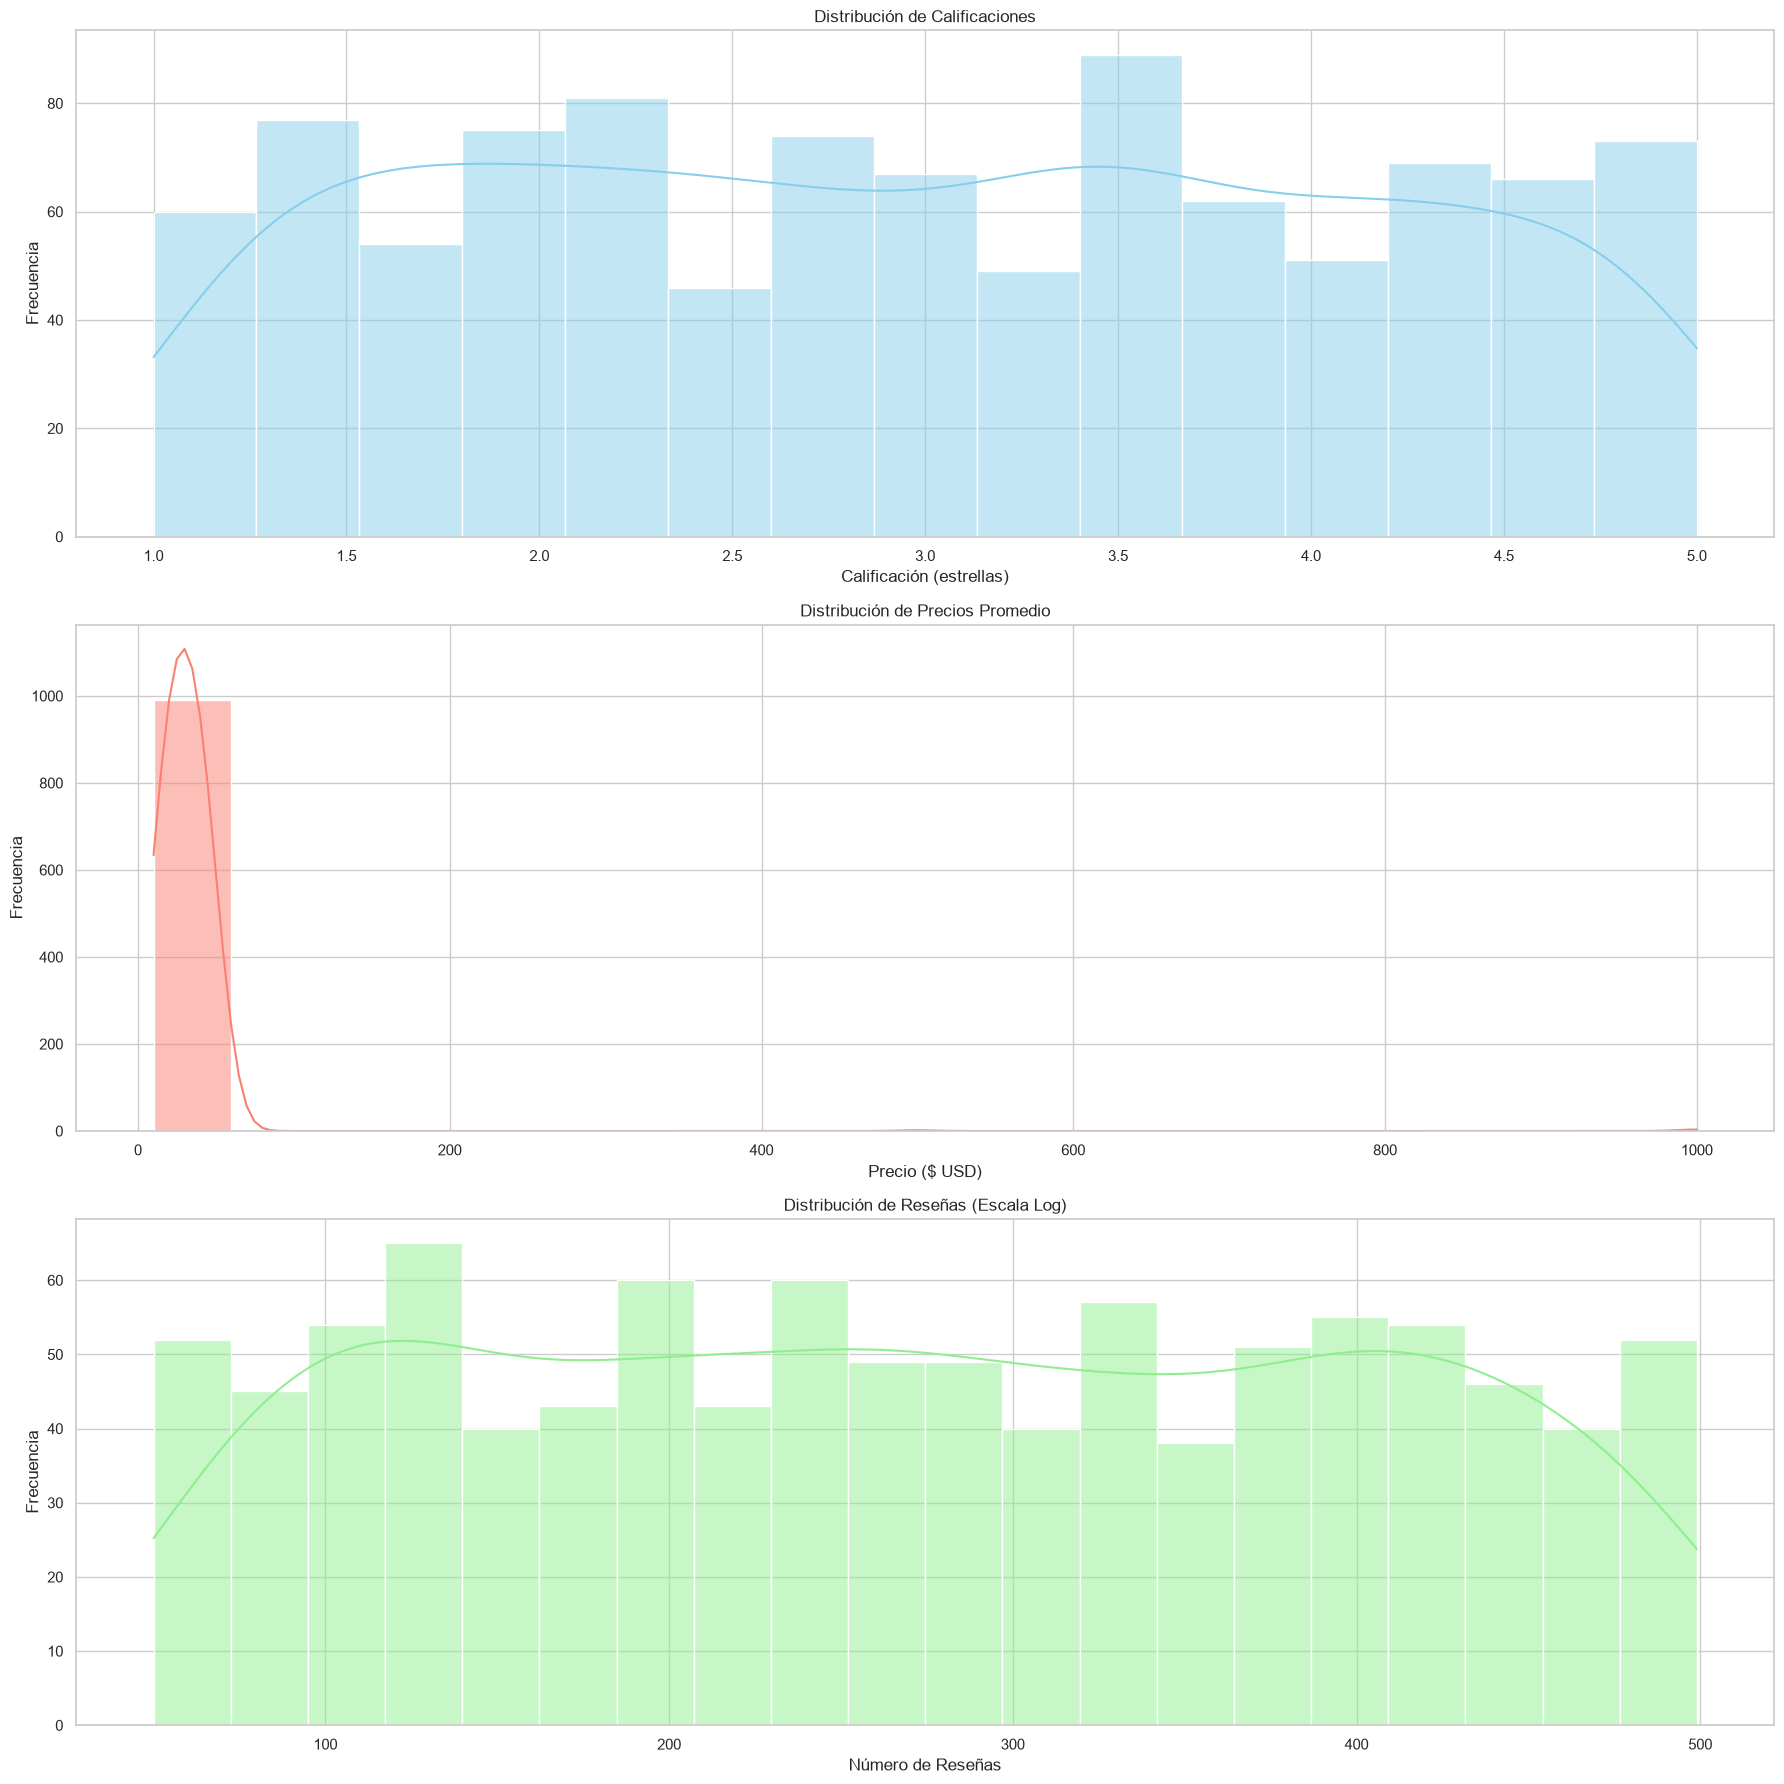

In [12]:
# ==============================================================================
# 4. VISUALIZACIONES CON MATPLOTLIB Y SEABORN
# ==============================================================================
print("\n--- 4. GENERANDO VISUALIZACIONES ---")

# Crear una figura compuesta (3 subgráficos en una fila para las distribuciones)
fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# Gráfico 1: Distribución de Calificaciones
sns.histplot(df_clean['Calificación'], bins=15, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Calificaciones')
axes[0].set_xlabel('Calificación (estrellas)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Distribución de Precios Promedio
sns.histplot(df_clean['Precio promedio (USD)'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Precios Promedio')
axes[1].set_xlabel('Precio ($ USD)')
axes[1].set_ylabel('Frecuencia')

# Gráfico 3: Distribución de Número de Reseñas
sns.histplot(df_clean['Número de reseñas'], bins=20, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Distribución de Reseñas (Escala Log)')
axes[2].set_xlabel('Número de Reseñas')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Categorías de Comida más Populares:
             conteo_datos  calif_prom  resenas_prom  precio_prom       peso
Categoría                                                                  
Peruana               165    2.838788    271.018182    30.412121  16.582915
Mexicana              147    2.978231    263.734694    29.333333  14.773869
China                 146    3.027397    286.684932    32.568493  14.673367
Francesa              146    2.913014    262.630137    34.821918  14.673367
Italiana              135    3.068889    270.703704    30.570370  13.567839
Japonesa              129    2.977519    278.480620    36.565891  12.964824
Colombiana            124    3.120161    269.419355    29.072581  12.462312
Desconocida             2    3.150000    170.000000    38.000000   0.201005
Fusión?                 1    3.000000    499.000000    46.000000   0.100503


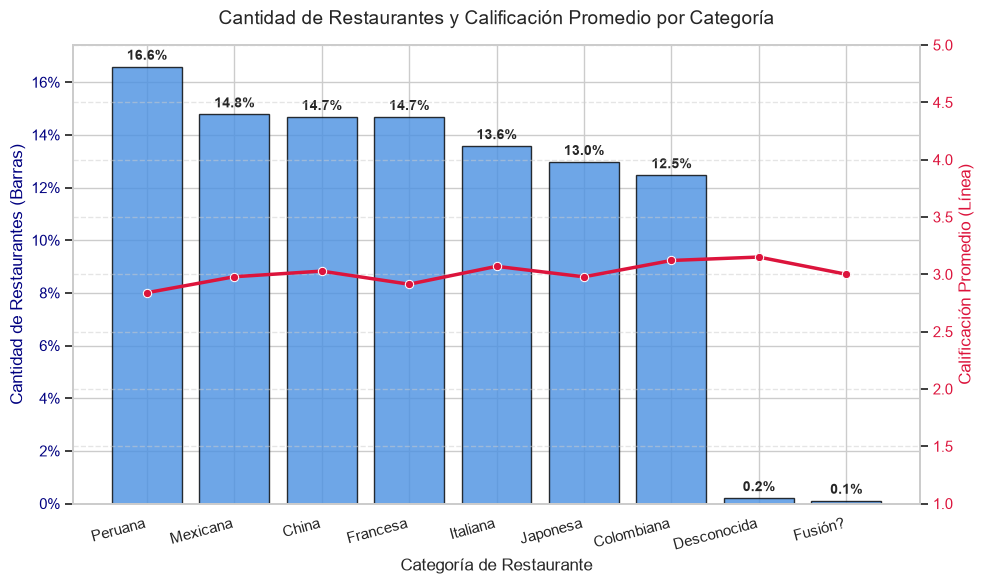

In [43]:
# ==============================================================================
# GRÁFICO 1: CATEGORÍAS DE COMIDA MÁS POPULARES
# ==============================================================================

print("\nCategorías de Comida más Populares:")

resumen_categorias = df_clean.groupby('Categoría').agg(
    conteo_datos = ('Categoría', 'count'),
    calif_prom = ('Calificación', 'mean'),
    resenas_prom = ('Número de reseñas', 'mean'),
    precio_prom = ('Precio promedio (USD)', 'mean')
).sort_values(by='conteo_datos', ascending=False)

resumen_categorias['peso'] = (resumen_categorias['conteo_datos']/len(df_clean))*100

print(resumen_categorias)

# 2. Crear la figura y el eje para el primer gráfico
fig1, ax1 = plt.subplots()

# 3. Dibujar el gráfico de barras verticales
barras1 = ax1.bar(range(len(resumen_categorias)),
                  resumen_categorias['peso'],
                  color='#4a90e2',
                  edgecolor='black',
                  alpha=0.8)

# 4. Añadir las etiquetas de porcentaje arriba de cada barra
# 'padding=3' empuja el texto ligeramente hacia arriba de la barra
ax1.bar_label(barras1,
              labels=[f'{p:.1f}%' for p in resumen_categorias['peso']],
              padding=3, 
              fontsize=10, 
              weight='bold')

# 5. Personalizar títulos y etiquetas
ax1.set_title('Top de Categorías de Comida más Populares en Colombia', 
              fontsize=14, 
              pad=15, 
              weight='bold')

ax1.set_title('Cantidad de Restaurantes y Calificación Promedio por Categoría', fontsize=14, pad=15)
ax1.set_xlabel('Categoría de Restaurante', fontsize=12)
ax1.set_ylabel('Cantidad de Restaurantes (Barras)', fontsize=12, color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))

plt.xticks(rotation=15, ha='right')

# 6. Crear el segundo eje Y compartido para el Linechart
ax2 = ax1.twinx()

# Gráfico de línea: Calificación promedio
sns.lineplot(
    data=resumen_categorias, 
    x='Categoría', 
    y='calif_prom', 
    ax=ax2, 
    color='crimson', 
    marker='o', 
    linewidth=2.5, 
    sort=False  # Mantiene el orden jerárquico establecido por el barplot
)

# Personalizar el segundo eje
ax2.set_ylabel('Calificación Promedio (Línea)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Ajustar los límites del eje Y de la calificación (opcional, ej: escala de 1 a 5)
ax2.set_ylim(1, 5)


# Rotar las etiquetas del eje X si los nombres de las categorías son largos

plt.tight_layout()
plt.show()


Concentración por Departamento:
   1. TOLIMA: 245 establecimientos (24.6%)
   2. ANTIOQUIA: 171 establecimientos (17.2%)
   3. CUNDINAMARCA: 135 establecimientos (13.6%)
   4. VALLE DEL CAUCA: 105 establecimientos (10.6%)
   5. CALDAS: 86 establecimientos (8.6%)
   6. CHOCO: 75 establecimientos (7.5%)
   7. RISARALDA: 59 establecimientos (5.9%)
   8. QUINDIO: 25 establecimientos (2.5%)
   9. META: 24 establecimientos (2.4%)
   10. SANTANDER: 23 establecimientos (2.3%)
   11. BOGOTA D.C.: 20 establecimientos (2.0%)
   12. BOYACA: 19 establecimientos (1.9%)
   13. HUILA: 8 establecimientos (0.8%)


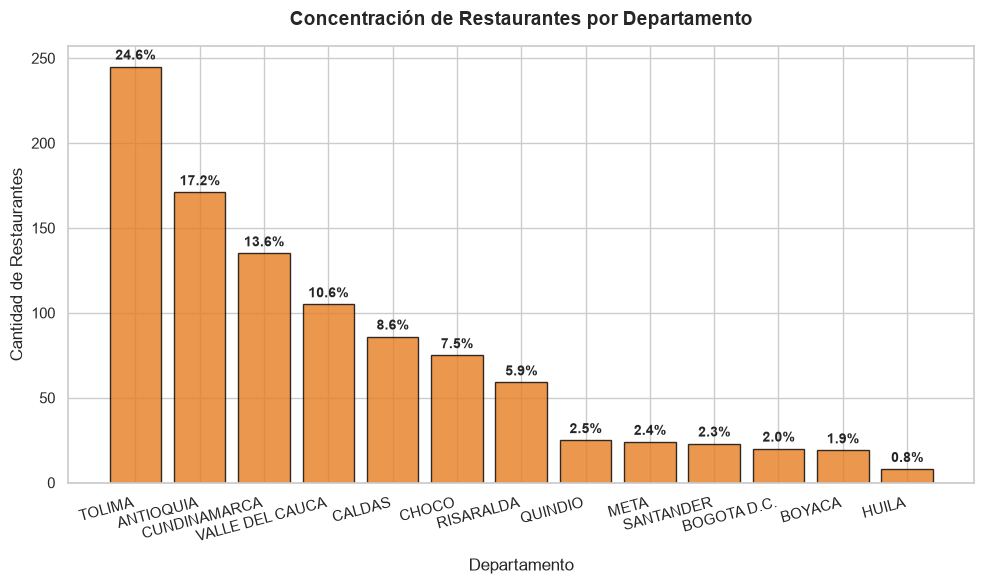

In [45]:
# ==============================================================================
# GRÁFICO 2: CONCENTRACIÓN DE RESTAURANTES POR DEPARTAMENTO
# ==============================================================================

print("\nConcentración por Departamento:")
conteo_dptos = df_clean['departamento'].value_counts()

# Desplegamos el ranking de departamentos
for i, (dpto, conteo) in enumerate(conteo_dptos.items(), 1):
    porcentaje = (conteo / len(df_clean)) * 100
    print(f"   {i}. {dpto}: {conteo} establecimientos ({porcentaje:.1f}%)")

porcentajes_dptos = (conteo_dptos / len(df_clean)) * 100

# 3. Crear la figura y el eje para el segundo gráfico
fig2, ax2 = plt.subplots()

# 4. Dibujar el gráfico de barras verticales con una paleta de color diferente
barras2 = ax2.bar(conteo_dptos.index, conteo_dptos.values, color='#e67e22', edgecolor='black', alpha=0.8)

# 5. Añadir las etiquetas de porcentaje arriba de cada barra
ax2.bar_label(barras2, labels=[f'{p:.1f}%' for p in porcentajes_dptos], padding=3, fontsize=10, weight='bold')

# 6. Personalizar títulos y etiquetas
ax2.set_title('Concentración de Restaurantes por Departamento', fontsize=14, pad=15, weight='bold')
ax2.set_xlabel('Departamento', fontsize=12, labelpad=10)
ax2.set_ylabel('Cantidad de Restaurantes', fontsize=12)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
# Actividad 2: Visualización Geoespacial con Folium

In [46]:
import folium
from folium.plugins import MarkerCluster
import json

In [57]:
# ==============================================================================
# MAPA 1: FILTRADO DE UN DEPARTAMENTO ESPECÍFICO
# ==============================================================================
# Definimos el departamento que deseamos revisar
DEPARTAMENTO_SELECCIONADO = "Antioquia"
print(f"\n-> Generando Mapa de Marcadores Interactivos para: {DEPARTAMENTO_SELECCIONADO}...")

# Filtramos el dataset original para conservar únicamente los restaurantes del territorio seleccionado
# Convertimos ambas variables en mayúsculas para evitar que se excluyan datos por la forma en que se almacenaron
df_filtrado = df_clean[df_clean['departamento'].str.upper() == DEPARTAMENTO_SELECCIONADO.upper()].copy()

# Validamos que el filtro contenga registros con coordenadas válidas antes de graficar
df_filtrado = df_filtrado.dropna(subset=['Latitud', 'Longitud'])

if not df_filtrado.empty:
    # Calculamos el centro geográfico del departamento seleccionado para enfocar el mapa automáticamente
    centro_lat = df_filtrado['Latitud'].mean()
    centro_lon = df_filtrado['Longitud'].mean()
    
    # Inicializamos el mapa con un nivel de zoom más cerrado (adecuado para ciudades/regiones)
    mapa_regional = folium.Map()
    
    # Añadimos la funcionalidad de agrupamiento (Cluster) para optimizar la visualización de los pines
    cluster_regional = MarkerCluster(name="Restaurantes").add_to(mapa_regional)
    
    # Recorremos cada restaurante filtrado para construir su marcador interactivo
    for idx, fila in df_filtrado.iterrows():
        # Plantilla HTML con diseño limpio para la ventana emergente al hacer clic (Popup)
        html_popup = f"""
        <div style="font-family: 'Segoe UI', Arial, sans-serif; width: 220px; font-size: 13px;">
            <h4 style="margin: 0 0 8px 0; color: #2c3e50; border-bottom: 2px solid #e67e22; padding-bottom: 3px;">
                {fila['Nombre']}
            </h4>
            <b>Categoría:</b> {fila['Categoría']}<br>
            <b>Calificación:</b> ⭐ {fila['Calificación']}<br>
            <b>Nro. Reseñas:</b> {fila['Número de reseñas']}<br>
            <b>Precio Promedio:</b> ${fila['Precio promedio (USD)']:,.0f} USD<br>
        </div>
        """
        popup = folium.Popup(html_popup, max_width=260)
        
        # Clasificamos el color del marcador según la excelencia del servicio (Calificación)
        color_indicador = 'green' if fila['Calificación'] >= 4.5 else ('orange' if fila['Calificación'] >= 3.5 else 'red')
        
        # Agregamos el marcador individual al contenedor del clúster regional
        folium.Marker(
            location=[fila['Latitud'], fila['Longitud']],
            popup=popup,
            tooltip=fila['Nombre'],
            icon=folium.Icon(color=color_indicador, icon='shop', prefix='fa') # Icono comercial de FontAwesome
        ).add_to(cluster_regional)
        
    # Desplegamos el primer mapa (Se dejan comentados para no cargar el archivo en GitHub)
    # display(mapa_coropleto)

    mapa_regional.save("mapa_restaurantes_" + DEPARTAMENTO_SELECCIONADO + ".html")
else:
    print(f"❌ Alerta: No se encontraron restaurantes registrados con coordenadas para el departamento '{DEPARTAMENTO_SELECCIONADO}'.")


-> Generando Mapa de Marcadores Interactivos para: Antioquia...


In [56]:
# ==============================================================================
# MAPA 2: MAPA DE COROPLETAS (Precios Promedio)
# ==============================================================================
print("-> Generando Mapa de Coropletas Nacional...")

# ==============================================================================
# 1. PREPARACIÓN DE LOS DATOS AGRUPADOS (Métricas por Departamento)
# ==============================================================================
# Agrupamos los datos para obtener el precio promedio y la calificación promedio por departamento
df_agrupado = df_clean.groupby('departamento').agg(
    precio_promedio=('Precio promedio (USD)', 'mean'),
    calificacion_promedio=('Calificación', 'mean'),
    resenas_promedio = ('Número de reseñas', 'mean'),
    cantidad_restaurantes=('departamento', 'count')
).reset_index()

# Forzamos a que los nombres de los departamentos estén en mayúsculas o coincidan 
# exactamente con el estándar de tu archivo GeoJSON/Shapefile
df_agrupado['departamento'] = df_agrupado['departamento'].str.strip()

# Convertimos nuestro mapa base local (mapa_local de GeoPandas creado anteriormente) a formato JSON para Folium
# Folium requiere la estructura GeoJSON para enlazar la propiedad 'key_on'
geojson_data = json.loads(mapa_local.to_json())

# Inicializamos el mapa centrado en Colombia
mapa_coropleto = folium.Map()

# Creamos la capa de Coropletas basada en el Precio Promedio
coropleth = folium.Choropleth(
    geo_data=geojson_data,                       # Estructura de los polígonos geográficos
    name="Precio Promedio por Departamento",
    data=df_agrupado,                            # Nuestro DataFrame con las métricas agrupadas
    columns=['departamento', 'precio_promedio'],      # [Columna Clave de enlace, Variable para el color]
    key_on="feature.properties.departamento", # Ruta de la propiedad clave dentro del GeoJSON (Ajústalo según tus columnas del SHP)
    fill_color="YlOrRd",                         # Escala de colores: Amarillo (Económico) a Rojo (Costoso)
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Precio Promedio de Restaurantes ($ USD)",
    highlight=True                               # Resalta el polígono cuando el cursor pasa por encima
).add_to(mapa_coropleto)

# Añadimos interactividad para mostrar AMBAS variables (Precios y Calificaciones) al pasar el cursor
# Convertimos el dataframe agrupado en un diccionario indexado para una consulta rápida en JavaScript
info_dict = df_agrupado.set_index('departamento').to_dict(orient='index')

# Agregamos los Tooltips dinámicos recorriendo las propiedades del GeoJSON
for feature in geojson_data['features']:
    nombre_dpto = feature['properties']['departamento']
    
    # Si el departamento tiene registros en nuestro dataset, extraemos sus métricas
    if nombre_dpto in info_dict:
        precio_val = f"${info_dict[nombre_dpto]['precio_promedio']:,.0f} USD"
        calif_val = f"⭐ {info_dict[nombre_dpto]['calificacion_promedio']:.2f}"
        cant_res = f"{info_dict[nombre_dpto]['resenas_promedio']:.0f} reseñas"
        cant_val = f"{info_dict[nombre_dpto]['cantidad_restaurantes']} locales"
        
    else:
        precio_val = "Sin datos"
        calif_val = "Sin datos"
        cant_res = "Sin reseñas"
        cant_val = "0 locales"
        
        
    # Inyectamos los datos calculados dentro de las propiedades del mapa interactivo
    feature['properties']['info_tooltip'] = (
        f"<b>Departamento:</b> {nombre_dpto}<br>"
        f"<b>Precio Promedio:</b> {precio_val}<br>"
        f"<b>Calificación Promed.:</b> {calif_val}<br>"
        f"<b>Nro. Reseñas Promed.:</b> {cant_res}<br>"
        f"<b>Restaurantes:</b> {cant_val}"
    )

# Añadimos la capa de interacción visual al mapa final
folium.GeoJson(
    geojson_data,
    style_function=lambda x: {'fillColor': '#transparent', 'color': 'transparent', 'weight': 0},
    tooltip=folium.GeoJsonTooltip(fields=['info_tooltip'], labels=False, localize=True)
).add_to(mapa_coropleto)

# Desplegamos el mapa (Se dejan comentados para no cargar el archivo en GitHub)
# display(mapa_coropleto)

# mapa_regional.save("mapa_restaurantes_coropletas_prec.html")

-> Generando Mapa de Coropletas Nacional...


In [55]:
# Inicializamos el mapa centrado en Colombia
mapa_coropleto = folium.Map()

# Creamos la capa de Coropletas basada en el Precio Promedio
coropleth = folium.Choropleth(
    geo_data=geojson_data,                       # Estructura de los polígonos geográficos
    name="Calificación Promedio por Departamento",
    data=df_agrupado,                            # Nuestro DataFrame con las métricas agrupadas
    columns=['departamento', 'calificacion_promedio'],      # [Columna Clave de enlace, Variable para el color]
    key_on="feature.properties.departamento", # Ruta de la propiedad clave dentro del GeoJSON (Ajústalo según tus columnas del SHP)
    fill_color="YlGnBu",                         # Escala de colores: Amarillo (Económico) a Rojo (Costoso)
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Calificación Promedio",
    highlight=True                               # Resalta el polígono cuando el cursor pasa por encima
).add_to(mapa_coropleto)

# Añadimos interactividad para mostrar AMBAS variables (Precios y Calificaciones) al pasar el cursor
# Convertimos el dataframe agrupado en un diccionario indexado para una consulta rápida en JavaScript
info_dict = df_agrupado.set_index('departamento').to_dict(orient='index')

# Agregamos los Tooltips dinámicos recorriendo las propiedades del GeoJSON
for feature in geojson_data['features']:
    nombre_dpto = feature['properties']['departamento']
    
    # Si el departamento tiene registros en nuestro dataset, extraemos sus métricas
    if nombre_dpto in info_dict:
        precio_val = f"${info_dict[nombre_dpto]['precio_promedio']:,.0f} USD"
        calif_val = f"⭐ {info_dict[nombre_dpto]['calificacion_promedio']:.2f}"
        cant_res = f"{info_dict[nombre_dpto]['resenas_promedio']:.0f} reseñas"
        cant_val = f"{info_dict[nombre_dpto]['cantidad_restaurantes']} locales"
        
    else:
        precio_val = "Sin datos"
        calif_val = "Sin datos"
        cant_res = "Sin reseñas"
        cant_val = "0 locales"
        
        
    # Inyectamos los datos calculados dentro de las propiedades del mapa interactivo
    feature['properties']['info_tooltip'] = (
        f"<b>Departamento:</b> {nombre_dpto}<br>"
        f"<b>Precio Promedio:</b> {precio_val}<br>"
        f"<b>Calificación Promed.:</b> {calif_val}<br>"
        f"<b>Nro. Reseñas Promed.:</b> {cant_res}<br>"
        f"<b>Restaurantes:</b> {cant_val}"
    )

# Añadimos la capa de interacción visual al mapa final
folium.GeoJson(
    geojson_data,
    style_function=lambda x: {'fillColor': '#transparent', 'color': 'transparent', 'weight': 0},
    tooltip=folium.GeoJsonTooltip(fields=['info_tooltip'], labels=False, localize=True)
).add_to(mapa_coropleto)

# Desplegamos el primer mapa (Se dejan comentados para no cargar el archivo en GitHub)
# display(mapa_coropleto)

# mapa_regional.save("mapa_restaurantes_coropletas_cal.html")